In [1]:
import pandas as pd
df = pd.read_csv("../datasets/processed/saas_features_processed.csv")

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [10]:
feature_columns = [
    "login_hour",
    "session_duration",
    "failed_login_count",
    "data_transfer_amount",
    "files_accessed",
    "emails_sent",
    "database_queries",
    "usb_usage",
    "vpn_usage",
    "is_weekend",
    "night_login",
    "business_hours",
    "sensitive_access",
    "external_ip",
    "high_transfer",
    "high_db_queries",
    "high_file_access",
    "failed_login_flag",
    "long_session",
    "login_deviation",
    "transfer_deviation",
    "session_deviation",
    "query_deviation",
    "file_deviation"
]

In [11]:
X = df[feature_columns]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X = df[feature_columns]
print(X.shape)

(111447, 24)


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
iso = IsolationForest(

    contamination=0.25,
    n_estimators=200,
    random_state=42

)

iso.fit(X_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,0.25
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [16]:
df["iso_prediction"] = iso.predict(X_scaled)

In [17]:
df["iso_prediction"].value_counts()

 1    83585
-1    27862
Name: iso_prediction, dtype: int64

In [18]:
df["iso_score"] = iso.decision_function(X_scaled)

In [19]:
df["iso_score"].describe()

count    111447.000000
mean          0.023623
std           0.074275
min          -0.321624
25%           0.000000
50%           0.051105
75%           0.074967
max           0.105369
Name: iso_score, dtype: float64

In [20]:
anomalies = df[df["iso_prediction"] == -1]
anomalies.head()

,company_id,user_id,login_time,login_hour,is_weekend,session_duration,failed_login_count,data_transfer_amount,files_accessed,emails_sent,...,avg_transfer,avg_files,avg_queries,login_deviation,transfer_deviation,session_deviation,query_deviation,file_deviation,iso_prediction,iso_score
3,T004,U00269,2025-02-17 14:51:43,22,0,185.7,0,135.3,5,0,...,202.892701,10.080292,7.459854,5.875912,67.592701,44.943796,0.540146,5.080292,-1,-0.055625
4,T005,U00383,2025-02-05 15:13:54,19,0,288.2,2,500.1,29,9,...,212.796667,10.333333,8.000000,6.758333,287.303333,4.830000,12.000000,18.666667,-1,-0.091331
7,T001,U00022,2025-02-10 03:49:39,7,0,264.7,3,562.6,25,5,...,341.068203,14.976959,11.230415,5.972350,221.531797,30.245622,5.769585,10.023041,-1,-0.112352
15,T008,U00603,2025-02-23 19:36:54,14,1,283.4,1,659.9,43,9,...,357.894828,10.919540,8.293103,0.178161,302.005172,12.676437,27.706897,32.080460,-1,-0.150583
21,T003,U00109,2025-02-13 15:58:23,8,0,325.2,1,285.7,20,7,...,221.819540,10.316092,8.367816,6.873563,63.880460,3.595402,11.632184,9.683908,-1,-0.019189


In [21]:
pred_binary = (df["iso_prediction"] == -1).astype(int)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    df["risk_label"],
    pred_binary
))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     82778
           1       0.68      0.66      0.67     28669

    accuracy                           0.83    111447
   macro avg       0.78      0.78      0.78    111447
weighted avg       0.83      0.83      0.83    111447



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["risk_label"],
    pred_binary
)

print(cm)

[[73928  8850]
 [ 9657 19012]]


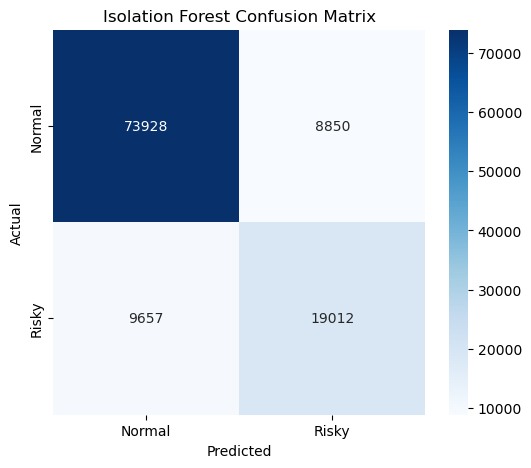

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Risky"],
    yticklabels=["Normal", "Risky"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")

plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(df["risk_label"], pred_binary))
print("Precision:", precision_score(df["risk_label"], pred_binary))
print("Recall   :", recall_score(df["risk_label"], pred_binary))
print("F1 Score :", f1_score(df["risk_label"], pred_binary))

Accuracy : 0.8339390023957576
Precision: 0.6823630751561266
Recall   : 0.6631553245666051
F1 Score : 0.6726221011480427


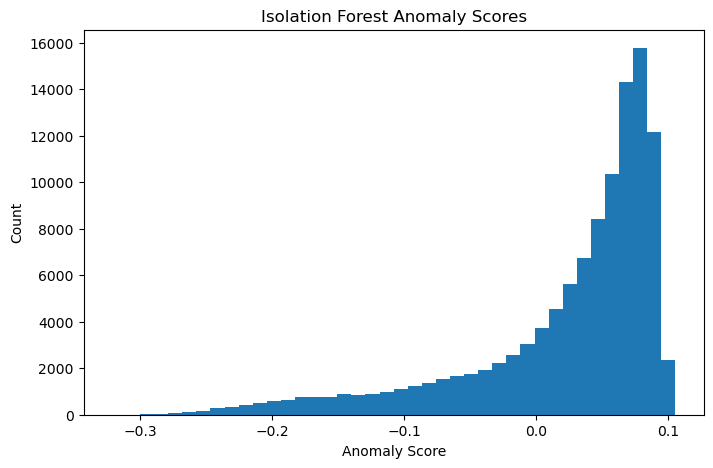

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["iso_score"], bins=40)

plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")

plt.show()